In [1]:
import pandas as pd
# import numpy as np (unused)
import matplotlib.pyplot as plt
import seaborn as sns
# import plotly.express as px (unused)
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/cleaned/'

# Load cleaned master table
master = pd.read_csv(DATA_PATH + 'master_orders.csv',
                     parse_dates=['order_purchase_timestamp',
                                  'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'])

products = pd.read_csv(DATA_PATH + 'products_cleaned.csv')
geo      = pd.read_csv(DATA_PATH + 'geolocation_cleaned.csv')

print("Cleaned tables loaded successfully!")
print(f"Master table: {master.shape[0]:,} rows x {master.shape[1]} columns")

Cleaned tables loaded successfully!
Master table: 99,441 rows x 22 columns


In [2]:
print(master.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_items', 'total_revenue', 'total_freight', 'total_payments', 'payment_types', 'installments', 'review_score', 'delivery_days', 'delivery_delay_days', 'is_complete']


Analysis 1 — Monthly Revenue Trend

In [3]:
# Filter complete orders only
complete = master[master['is_complete']].copy()

# Extract year-month for grouping
complete['year_month'] = complete['order_purchase_timestamp'].dt.to_period('M')

# Group by month
monthly_revenue = complete.groupby('year_month').agg(
    revenue = ('total_revenue', 'sum'),
    orders = ('order_id', 'count')
).reset_index()

monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

print(f"Monthly revenue data: {len(monthly_revenue)} months")
print(monthly_revenue.head(10))

Monthly revenue data: 24 months
  year_month    revenue  orders
0    2016-09     267.36       3
1    2016-10   49507.66     308
2    2016-12      10.90       1
3    2017-01  120312.87     789
4    2017-02  247303.02    1733
5    2017-03  374344.30    2641
6    2017-04  359927.23    2391
7    2017-05  506071.14    3660
8    2017-06  433038.60    3217
9    2017-07  498031.48    3969


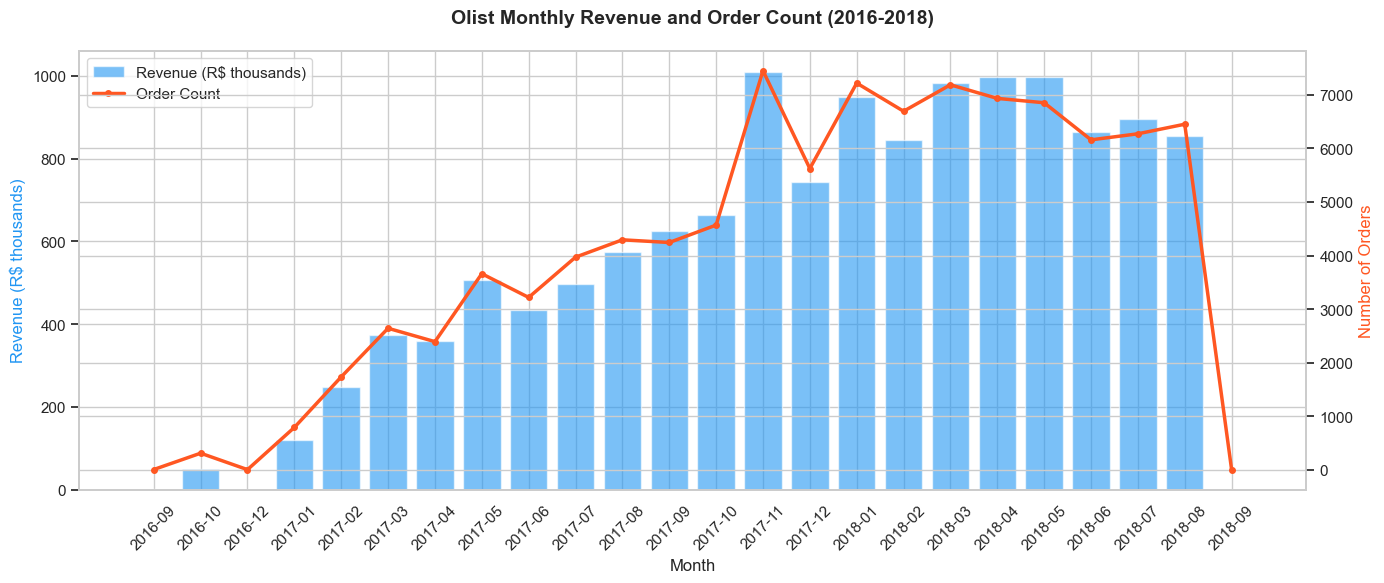

Chart saved to reports/


In [4]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6))

#Revenue bars
ax1.bar(monthly_revenue['year_month'],
        monthly_revenue['revenue'] / 1000,
        color = '#2196F3', alpha=0.6, label='Revenue (R$ thousands)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (R$ thousands)', color='#2196F3')
ax1.tick_params(axis='x', rotation=45)

# Orders count line
ax2 = ax1.twinx()
ax2.plot(monthly_revenue['year_month'],
         monthly_revenue['orders'],
         color='#FF5722', linewidth=2.5,
         marker='o', markersize=4, label='Order Count')
ax2.set_ylabel('Number of Orders', color='#FF5722')

# Title and legends
plt.title('Olist Monthly Revenue and Order Count (2016-2018)', 
          fontsize=14, fontweight='bold', pad=20
          )

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/01_monthly_revenue_trend.png', 
            dpi=300, bbox_inches='tight'
            )
plt.show()
print("Chart saved to reports/")

Growth phase (Sep 2016 → Nov 2017):

Olist grew from virtually zero to R$1 million/month in just 14 months
Order count and revenue grew almost perfectly in sync — healthy growth

Peak (November 2017):

Highest single month — ~R$1 million revenue, ~7,000 orders
Likely driven by Black Friday (biggest shopping day in Brazil)

Plateau (Dec 2017 → Aug 2018):

Revenue stabilised around R$850k–R$1M per month
Business reached maturity — consistent but not explosive growth

Sharp drop (Sep 2018):

Orders and revenue both crash — this is not a real drop
The dataset ends in October 2018 so September is incomplete data

Analysis 2 — Revenue by Product Category 

In [5]:
# Join master with products to get category info
orders_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products     = pd.read_csv('../data/cleaned/products_cleaned.csv')

# Merge items with products to get categories
items_with_cat = orders_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id', 
    how='left'
)

# Revenue by category
category_revenue = items_with_cat.groupby('product_category_name').agg(
    revenue=('price', 'sum'),
    orders_count=('order_id', 'nunique'),
    avg_price=('price', 'mean')
).reset_index()

# Sort by revenue and take top 15
top15 = category_revenue.sort_values('revenue', ascending=False).head(15)

print("Top 15 categories by revenue:")
print(top15[['product_category_name', 
             'revenue',
             'orders_count', 
             'avg_price'
             ]
            ].to_string(index=False)
      )

Top 15 categories by revenue:
 product_category_name    revenue  orders_count  avg_price
          beleza_saude 1258681.34          8836 130.163531
    relogios_presentes 1205005.68          5624 201.135984
       cama_mesa_banho 1036988.68          9417  93.296327
         esporte_lazer  988048.97          7720 114.344285
informatica_acessorios  911954.32          6689 116.513903
      moveis_decoracao  729762.49          6449  87.564494
            cool_stuff  635290.85          3632 167.357969
 utilidades_domesticas  632248.66          5884  90.788148
            automotivo  592720.11          3897 139.957523
    ferramentas_jardim  485256.46          3518 111.630196
            brinquedos  483946.60          3886 117.548360
                 bebes  411764.89          2885 134.344173
            perfumaria  399124.87          3162 116.737312
             telefonia  323667.53          4199  71.213978
     moveis_escritorio  273960.70          1273 162.011059


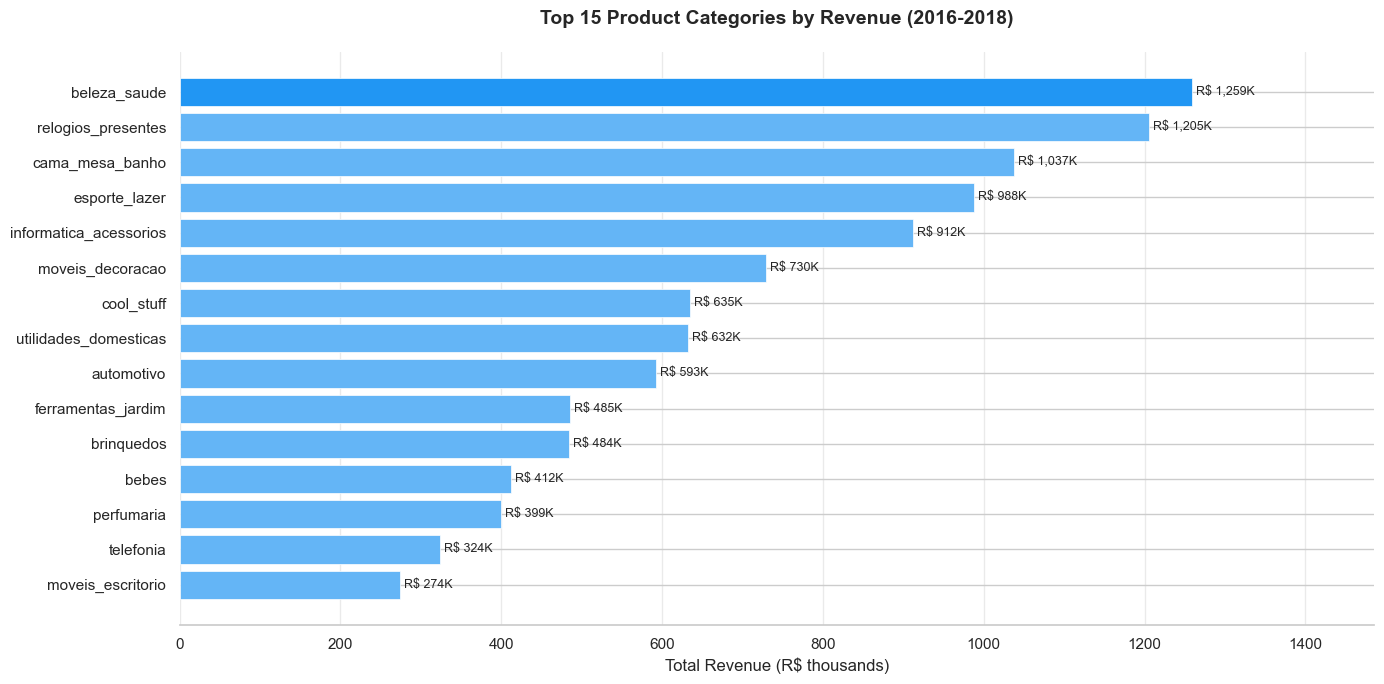

Chart saved: reports/02_top_categories_revenue.png ✅


In [6]:
# Analysis 2 - Revenue by Product Category (Chart)
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#2196F3' 
          if i == 0 
          else '#64B5F6'
          for i in range(len(top15))
          ]

bars = ax.barh(
    top15['product_category_name'], 
    top15['revenue'] / 1000, 
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels on bars
for bar, val in zip(bars, top15['revenue'] / 1000):
    ax.text(bar.get_width() + 5,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {val:,.0f}K',
            va='center', 
            fontsize=9
            )
    
ax.set_xlabel('Total Revenue (R$ thousands)', 
              fontsize=12)
ax.set_title('Top 15 Product Categories by Revenue (2016-2018)', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()  # Highest revenue on top
ax.set_xlim(0, top15['revenue'].max() / 1000 * 1.18) # room for labels
ax.grid(axis='x', alpha=0.4)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig('../reports/02_top_categories_revenue.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: reports/02_top_categories_revenue.png ✅")

# Analysis 2 — Key Insights
print("""
═══════════════════════════════════════════════════════
ANALYSIS 2 — REVENUE BY CATEGORY: KEY INSIGHTS
═══════════════════════════════════════════════════════

🥇 Top earner: beleza_saude (Health & Beauty) — R$1.26M
   → Highest order count in top 5 (8,836 orders)
   → Mid-range avg price (R$130) — high volume play

🥈 relogios_presentes (Watches & Gifts) — R$1.20M
   → Fewest orders in top 3 (5,624) but highest avg price (R$201)
   → Premium, low-volume category

📦 Volume leaders (orders > 8,000):
   → cama_mesa_banho: 9,417 orders (R$93 avg) — everyday essentials
   → beleza_saude:    8,836 orders (R$130 avg)

💰 Premium categories (avg price > R$150):
   → relogios_presentes: R$201
   → cool_stuff:         R$167
   → moveis_escritorio:  R$162

📌 Story note:
   "Brazilian shoppers on Olist skew toward lifestyle & wellness —
   Health/Beauty and Watches alone account for R$2.46M (17%) of 
   all category revenue. Tech (informatica) ranks 5th, not 1st,
   suggesting this is a lifestyle-driven marketplace."
═══════════════════════════════════════════════════════
""")

Analysis 3 — Delivery Performance by Seller State

In [7]:
# Analysis of delivery times by state
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')

# Join items -> sellers -> master (for delivery times)
items_sellers = order_items.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id', how='left'
)

delivery_by_state = items_sellers.merge(
    master[['order_id', 'delivery_days', 'review_score', 'is_complete']],
    on='order_id', how='left'
)

# Filter complete orders only
delivery_by_state = delivery_by_state[delivery_by_state['is_complete']]

#Aggregate by seller state
state_pref = delivery_by_state.groupby('seller_state').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    avg_review_score=('review_score', 'mean'),
    orders_count=('order_id', 'nunique')
).reset_index()

# Keep states with meaningful volume
state_pref = state_pref[state_pref['orders_count'] >= 1000].sort_values('avg_delivery_days')

print(state_pref.to_string(index=False))

seller_state  avg_delivery_days  avg_review_score  orders_count
          RS          11.092208          4.216353          1989
          RJ          11.554916          4.101194          4353
          SP          11.811387          4.005651         70188
          MG          12.329691          4.106894          7930
          PR          12.921763          4.073403          7673
          SC          13.095500          4.095426          3667


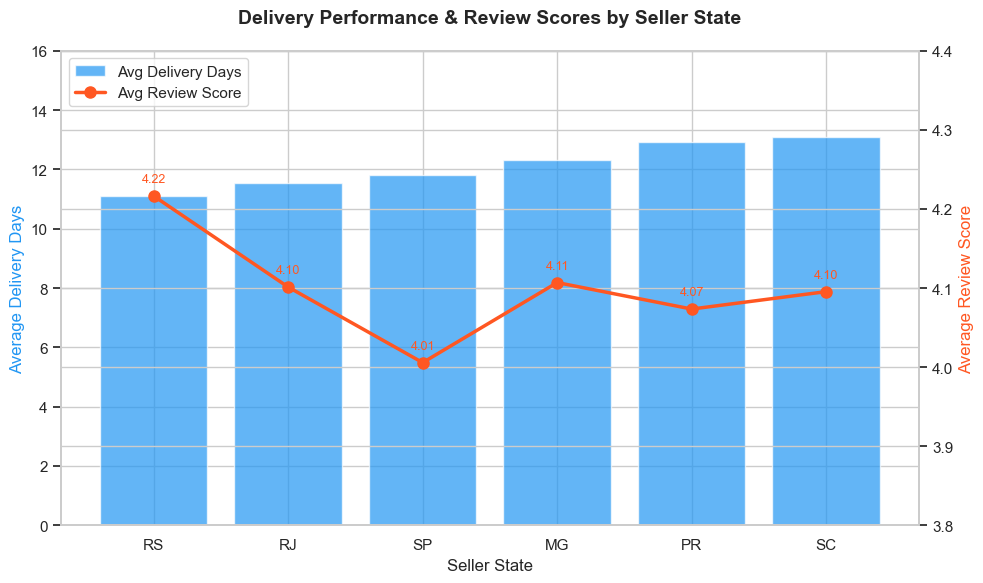

Chart saved: reports/03_delivery_review_by_state.png ✅


In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))

state_pref_sorted = state_pref.sort_values('avg_delivery_days')

x = range(len(state_pref_sorted))

bars = ax1.bar(x, state_pref_sorted['avg_delivery_days'], 
               color='#2196F3', 
               alpha=0.7,
               label = 'Avg Delivery Days'
               )
ax1.set_ylabel('Average Delivery Days', color='#2196F3')
ax1.set_ylim(0, 16)

ax2 = ax1.twinx()
ax2.plot(x, state_pref_sorted['avg_review_score'],
         color='#FF5722',
         linewidth=2.5,
         marker='o', 
         markersize=8,
         label='Avg Review Score'
         )
ax2.set_ylabel('Average Review Score', color='#FF5722')
ax2.set_ylim(3.8, 4.4)

for i, (x_pos, score) in enumerate (zip(x, state_pref_sorted['avg_review_score'])):
    ax2.annotate(f'{score:.2f}',
                 xy=(x_pos, score),
                 xytext=(0,10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=9,
                 color='#FF5722'
                 )

ax1.set_xticks(x)
ax1.set_xticklabels(state_pref_sorted['seller_state'])
ax1.set_xlabel('Seller State')

plt.title('Delivery Performance & Review Scores by Seller State',
          fontsize=14, fontweight='bold', pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/03_delivery_review_by_state.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: reports/03_delivery_review_by_state.png ✅")

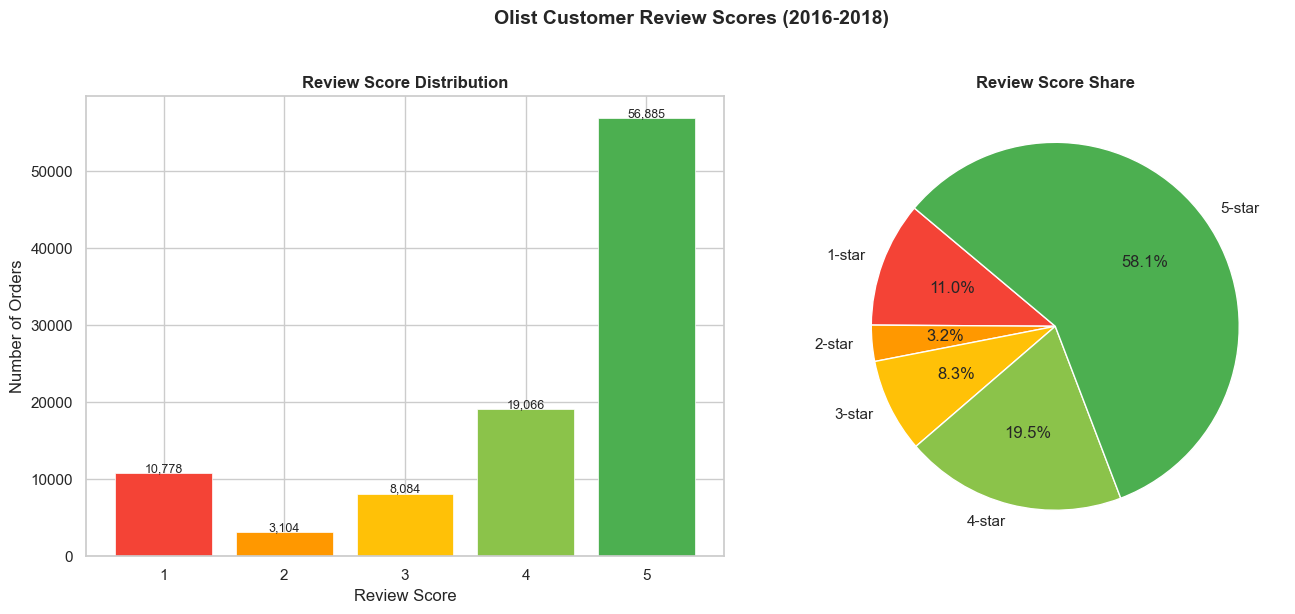

Chart saved: reports/04_review_score_distribution.png ✅


In [9]:
plt.rcParamsDefault['font.family'] = 'DejaVu Sans'

# Analysis 4 - Review Score Distribution
complete = master[master['is_complete']].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Left: count of each score
score_counts = (
    complete['review_score']
    .round()
    .astype('Int64')
    .value_counts()
    .sort_index()
    )
score_counts = score_counts[score_counts.index.isin([1, 2, 3, 4, 5])]
axes[0].bar(score_counts.index, score_counts.values,
            color=['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50'],
            edgecolor='white', 
            linewidth=0.5
            )
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Review Score Distribution',
                  fontweight='bold'
                  )
for i, (score, count) in enumerate(score_counts.items()):
    axes[0].text(score, count + 200, 
                 f'{count:,}', 
                 ha='center', 
                 fontsize=9
                 )
    
# Right: percantage breakdown
score_pct = score_counts / score_counts.sum() * 100
axes[1].pie(score_pct.values,
            labels=[f'{int(i)}-star' for i in score_pct.index],
            autopct='%1.1f%%',
            colors=['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50'],
            startangle=140
            )
axes[1].set_title('Review Score Share',
                  fontweight='bold'
                  )

plt.suptitle('Olist Customer Review Scores (2016-2018)',
             fontsize=14, fontweight='bold', y=1.02
             )
plt.tight_layout()
plt.savefig('../reports/04_review_score_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: reports/04_review_score_distribution.png ✅")

📌 58.1% of orders receive a 5-star review — majority of customers are happy
📌 11.0% give 1 star — the "silent killer" segment worth watching
📌 Scores 2 and 3 together are only 11.5% — reviews are polarised,
   customers either love it or hate it, not much middle ground
📌 77.6% of reviews are 4 or 5 stars — overall platform health is strong

In [10]:
# Analysis 5 - Correlation between Delivery Time and Review Score
complete = master[master['is_complete']].copy()

# Filter to orders that were actually delivered
delivered = complete[complete['delivery_days'].notnull() &
                     complete['review_score'].notnull()
                     ].copy()

# Round review score to nearest integer for better visualization
delivered['review_score_int'] = delivered['review_score'].round().astype('Int64')

# Average delivery delay per review score
delay_by_score = delivered.groupby('review_score_int').agg(
    avg_delay = ('delivery_delay_days', 'mean'),
    avg_delivery = ('delivery_days', 'mean'),
    order_count = ('order_id', 'count')
).reset_index()

print(delay_by_score.to_string(index=False))

 review_score_int  avg_delay  avg_delivery  order_count
                1  -4.026191     20.877845         9316
                2  -8.617468     16.221056         2954
                3 -10.780093     13.780346         7917
                4 -12.383267     11.844550        18945
                5 -13.383435     10.213888        56698


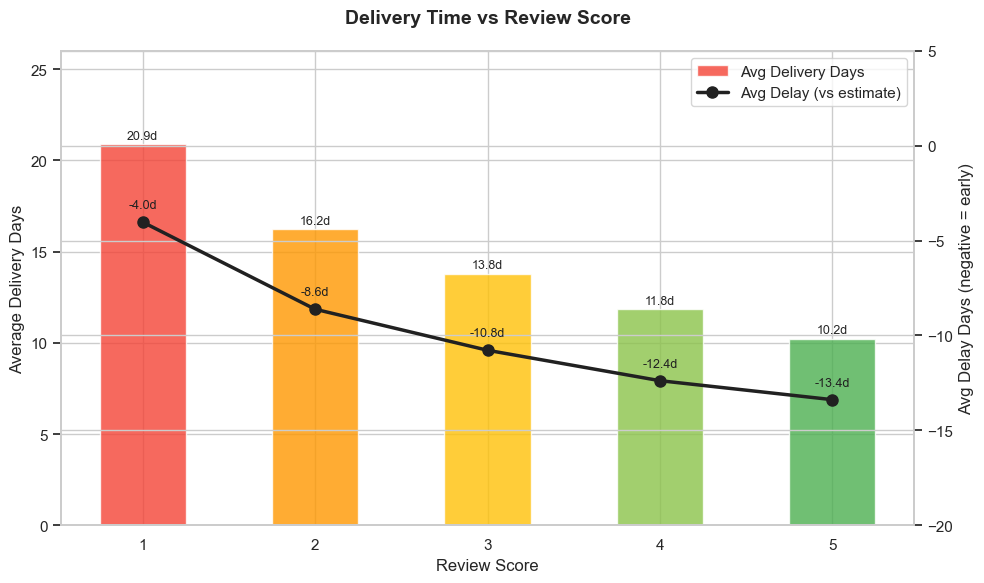

Chart saved: reports/05_delivery_vs_review.png ✅


In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = delay_by_score['review_score_int'].astype(int)
colors = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']

bars = ax1.bar(x, delay_by_score['avg_delivery'], 
               color=colors,
               alpha=0.8,
               width=0.5,
               label='Avg Delivery Days'
               )
ax1.set_ylabel('Average Delivery Days', fontsize=12)
ax1.set_ylim(0, 26)

for bar, val in zip(bars, delay_by_score['avg_delivery']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.1f}d',
             ha='center',
             fontsize=9
             )
    
ax2 = ax1.twinx()
ax2.plot(x, delay_by_score['avg_delay'],
         color='#212121',
         linewidth=2.5,
         marker='o',
         markersize=8,
         label='Avg Delay (vs estimate)'
         )

for i, (xi, val) in enumerate(zip(x,delay_by_score['avg_delay'])):
    ax2.annotate(f'{val:.1f}d',
                 xy=(xi, val),
                 xytext=(0,10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=9,
                 color='#212121'
                )
    
ax2.set_ylabel('Avg Delay Days (negative = early)', fontsize=12)
ax2.set_ylim(-20, 5)

ax1.set_xlabel('Review Score')
ax1.set_xticks([1, 2, 3, 4, 5])
plt.title('Delivery Time vs Review Score',
          fontsize=14, fontweight='bold', pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('../reports/05_delivery_vs_review_score.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: reports/05_delivery_vs_review.png ✅")

📌 Perfect monotonic relationship — every star level, no exceptions:
   1-star: 20.9 days delivery, only 4 days early
   5-star: 10.2 days delivery, 13.4 days early

📌 1-star customers waited TWICE as long as 5-star customers
   (20.9 days vs 10.2 days)

📌 Even 1-star orders arrived early on average — meaning Olist's
   buffer strategy works, but not enough to save the experience
   when actual delivery is slow

📌 Story note:
   "Delivery speed is the single clearest driver of customer
   satisfaction on Olist. Cut delivery time in half and you
   move from 1-star to 5-star territory."

In [12]:
# Analysis 6 - RFM Customer Segmentation
import pandas as pd
#import numpy as np

complete = master[master['is_complete']].copy()

# Reference date - day after last order in dataset
reference_date = complete['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = complete.groupby('customer_unique_id').agg(
    recency = ('order_purchase_timestamp',
               lambda x: (reference_date - x.max()).days
               ),
    frequency = ('order_id', 'count'),
    monetary = ('total_revenue', 'sum')
).reset_index()

# Score each dimension 1-5 (5 = best)
rfm['r_score'] = pd.qcut(rfm['recency'], 
                         q=5,
                         labels=[5,4,3,2,1]
                         )
rfm['f_score'] = pd.qcut(rfm['frequency']
                         .rank(method='first'),
                         q=5,
                         labels=[1,2,3,4,5]
                         )
rfm['m_score'] = pd.qcut(rfm['monetary'], 
                         q=5,
                         labels=[1,2,3,4,5]
                         )

rfm['rfm_score'] = (rfm['r_score'].astype(int) +
                    rfm['f_score'].astype(int) +
                    rfm['m_score'].astype(int)
                    )

# Segment labels
def segment (score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'
    
rfm['segment'] = rfm['rfm_score'].apply(segment)

print(rfm['segment'].value_counts())
print(f"\nTotal customers: {len(rfm):,}")
print("\nRFM preview:")
print(rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'rfm_score', 'segment']]
      .head(10).to_string(index=False))

segment
Potential Loyalists    39343
Loyal Customers        31969
At Risk                12694
Champions               8102
Lost                    3312
Name: count, dtype: int64

Total customers: 95,420

RFM preview:
              customer_unique_id  recency  frequency  monetary  rfm_score             segment
0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90          9 Potential Loyalists
0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90          6             At Risk
0000f46a3911fa3c0805444483337064      542          1     69.00          4                Lost
0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99          4                Lost
0004aac84e0df4da2b147fca70cf8255      293          1    180.00          8 Potential Loyalists
0004bd2a26a76fe21f786e4fbd80607f      151          1    154.00          9 Potential Loyalists
00050ab1314c0e55a6ca13cf7181fecf      136          1     27.99          6             At Risk
00053a61a98854899e70ed204dd4ba

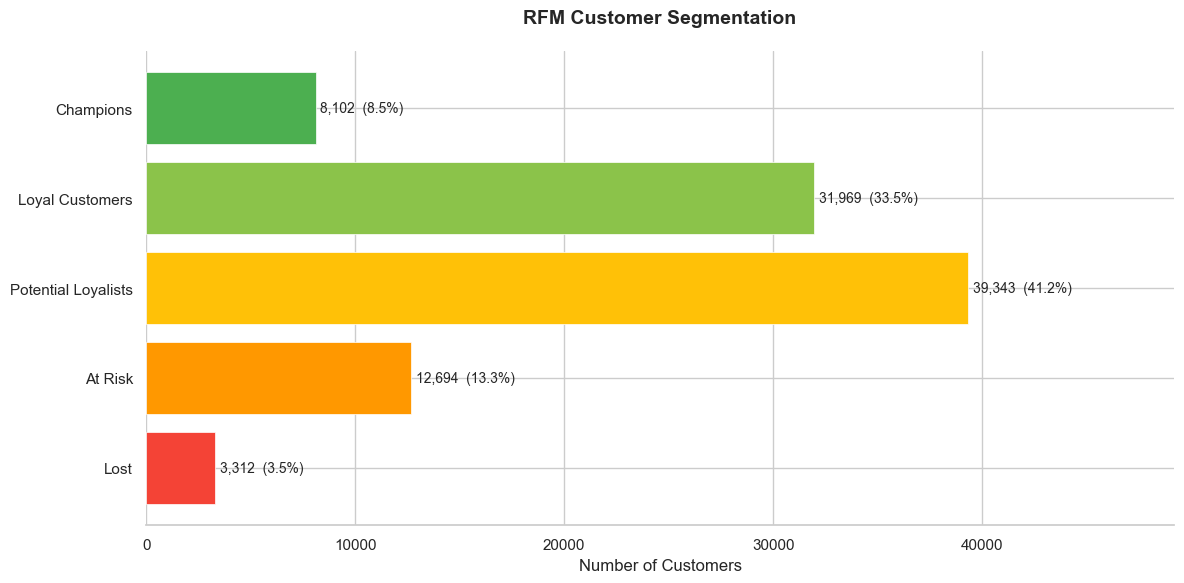

Chart saved: reports/06_rfm_segmentation.png ✅


In [13]:
segment_order = ['Champions', 'Loyal Customers', 
                 'Potential Loyalists', 'At Risk', 'Lost']
segment_colors = {
    'Champions'          : '#4CAF50',
    'Loyal Customers'    : '#8BC34A',
    'Potential Loyalists': '#FFC107',
    'At Risk'            : '#FF9800',
    'Lost'               : '#F44336'
}

seg_counts = rfm['segment'].value_counts().reindex(segment_order)
seg_pct    = seg_counts / seg_counts.sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(seg_counts.index,
               seg_counts.values,
               color=[segment_colors[s] for s in seg_counts.index],
               edgecolor='white', linewidth=0.5)

for bar, count, pct in zip(bars, seg_counts.values, seg_pct.values):
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height() / 2,
            f'{count:,}  ({pct:.1f}%)',
            va='center', fontsize=10)

ax.set_xlabel('Number of Customers')
ax.set_title('RFM Customer Segmentation',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, seg_counts.max() * 1.25)
ax.invert_yaxis()
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig('../reports/06_rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: reports/06_rfm_segmentation.png ✅")

📌 41.2% Potential Loyalists — the biggest opportunity segment.
   They've bought recently but not enough to be loyal yet.
   A re-engagement campaign here could move the needle most.

📌 33.5% Loyal Customers — solid base, already committed to the platform

📌 13.3% At Risk — bought before but going quiet. 
   Need intervention before they become Lost.

📌 Only 8.5% Champions — the high-value repeat buyers are a 
   small elite. Protecting this group should be top priority.

📌 3.5% Lost — small enough that it's not a crisis,
   but worth understanding why they left.

📌 Story note:
   "Olist's biggest challenge isn't losing customers —
   it's converting one-time buyers into repeat ones.
   41% of customers are one purchase away from loyalty."

In [14]:
# Analysis 7 - Cohort Analysis
complete = master[master['is_complete']].copy()

# Get each customer's first purchase month (acquisition cohort)
complete['order_month'] = complete['order_purchase_timestamp'].dt.to_period('M')

first_purchase = complete.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']

# Join cohort back to orders
complete = complete.merge(first_purchase, 
                          on='customer_unique_id', 
                          how='left'
                          )

# Calculate months since first purchase
complete['months_since_first'] = (
    complete['order_month'] - complete['cohort_month']
).apply(lambda x: x.n)

# Build cohort Pivot
cohort_table = complete.groupby(['cohort_month', 'months_since_first'])\
                       .agg(customers=('customer_unique_id', 'nunique'))\
                       .reset_index()
                       
cohort_pivot = cohort_table.pivot(index = 'cohort_month',
                                  columns = 'months_since_first',
                                  values = 'customers'
                                  )

# Retention rate - divide each column by month 0 (new customers)
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

# Keep cohorts with enough history (first 12 months, drop last 3)
retention = retention.iloc[:-3, :13]

print("Cohort size (new customers per month):")
print(cohort_size.iloc[:-3].to_string())
print(f"\nRetention table shape: {retention.shape}")

Cohort size (new customers per month):
cohort_month
2016-09       3.0
2016-10     305.0
2016-12       1.0
2017-01     754.0
2017-02    1705.0
2017-03    2595.0
2017-04    2339.0
2017-05    3560.0
2017-06    3114.0
2017-07    3843.0
2017-08    4149.0
2017-09    4090.0
2017-10    4412.0
2017-11    7217.0
2017-12    5442.0
2018-01    6983.0
2018-02    6422.0
2018-03    6947.0
2018-04    6709.0
2018-05    6604.0
Freq: M

Retention table shape: (20, 13)


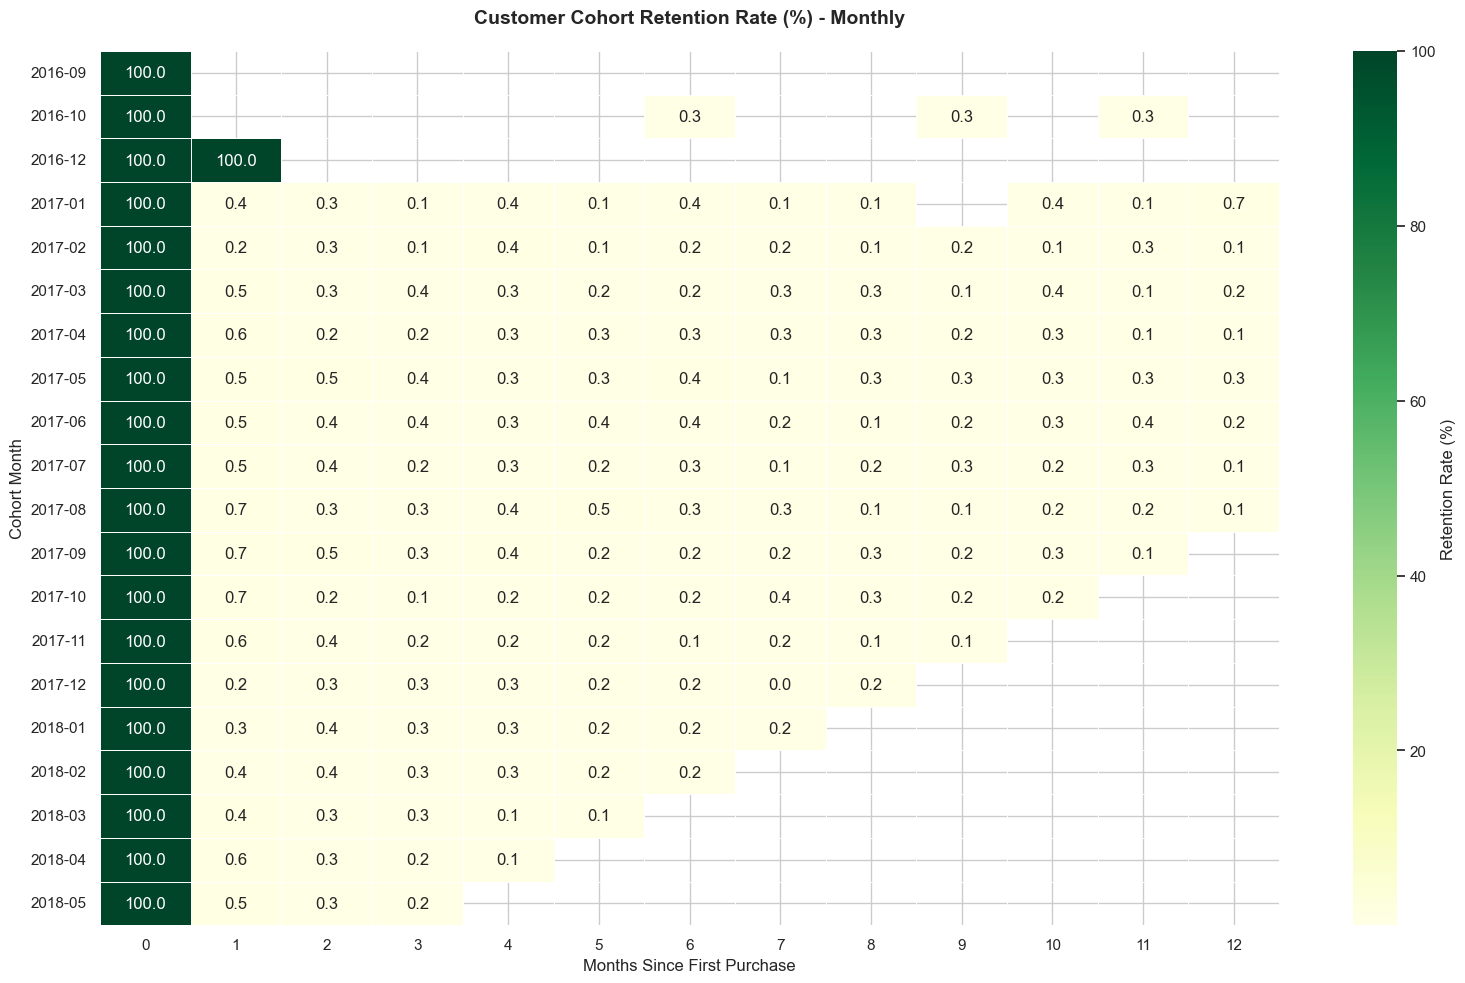

Chart saved: reports/07_cohort_retention.png ✅


In [15]:
# Analysis 7 - Cohort Retention Heatmap
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(retention,
            annot=True,
            fmt='.1f',
            cmap='YlGn',
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Retention Rate (%)'},
            mask=retention.isnull()
            )

ax.set_title('Customer Cohort Retention Rate (%) - Monthly',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort Month', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../reports/07_cohort_retention.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: reports/07_cohort_retention.png ✅")

📌 Retention drops to below 1% by Month 1 — virtually nobody 
   comes back the very next month after their first purchase

📌 Across all cohorts, Month 1 retention is 0.2%–0.7% — 
   that's not a rounding error, it's a structural problem

📌 The pattern is completely flat across all cohorts and all months —
   Olist never cracked the repeat purchase problem at any point 
   in its growth from 2016 to 2018

📌 2016-12 cohort shows 100% in Month 1 — but that cohort 
   only had 1 customer (from the cohort size output), 
   so it's statistically meaningless

📌 Story note:
   "Olist grew to R$1M/month entirely on new customer acquisition.
   Retention never exceeded 1% in any cohort, in any month.
   The engine was always: find new customers, not keep old ones.
   That's an expensive way to run a marketplace."

In [16]:
# Analysis 8 - Seller Performance Scorecard
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')

# Join items -> master (for review score and delivery days)
items_master = order_items.merge(
    master[['order_id', 'review_score', 'delivery_days', 'is_complete']],
    on='order_id', how='left'
)

# Filter complete orders only
items_master = items_master[items_master['is_complete']]

# Aggregate by seller
seller_scores = items_master.groupby('seller_id').agg(
    total_revenue = ('price', 'sum'),
    total_orders = ('order_id', 'nunique'),
    avg_review_score = ('review_score', 'mean'),
    avg_delivery_days = ('delivery_days', 'mean')
).reset_index()

# Join seller state
seller_scores = seller_scores.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id', how='left'
)

# Keep sellers with meaningful volume
seller_scores = seller_scores[seller_scores['total_orders'] >= 10]

print(f"Sellers with 10+ orders: {len(seller_scores):,}")
print("\nTop 10 sellers by revenue:")
print(seller_scores.nlargest(10, 'total_revenue')[
    ['seller_id', 'seller_state', 'total_revenue', 'total_orders', 'avg_review_score', 'avg_delivery_days']
    ].to_string(index=False)
)

Sellers with 10+ orders: 1,271

Top 10 sellers by revenue:
                       seller_id seller_state  total_revenue  total_orders  avg_review_score  avg_delivery_days
4869f7a5dfa277a7dca6462dcf3b52b2           SP      229472.63          1132          4.122822          14.549652
53243585a1d6dc2643021fd1853d8905           BA      222776.05           358          4.075980          12.940000
4a3ca9315b744ce9f8e9374361493884           SP      200472.92          1806          3.803262          13.939456
fa1c13f2614d7b5c4749cbc52fecda94           SP      194042.03           585          4.340206          12.839378
7c67e1448b00f6e969d365cea6b010ab           SP      187923.89           982          3.341445          21.945387
7e93a43ef30c4f03f38b393420bc753a           SP      176431.87           336          4.206490          10.832298
da8622b14eb17ae2831f4ac5b9dab84a           SP      160236.57          1314          4.063754          10.698320
7a67c85e85bb2ce8582c35f2203ad736           SP

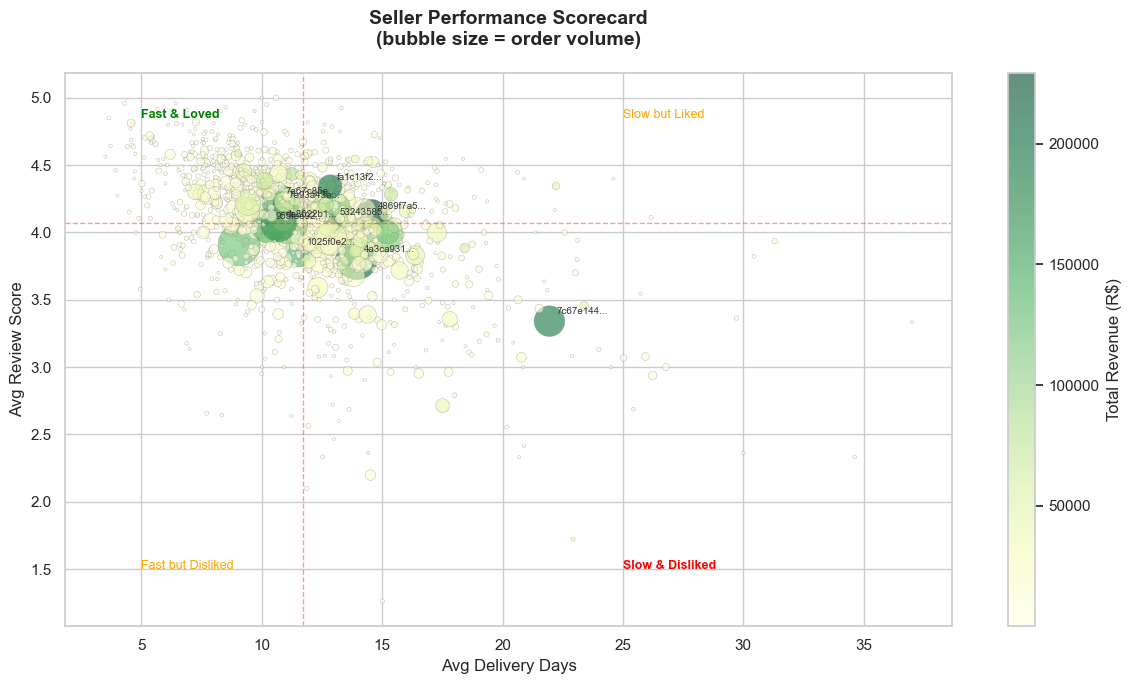

Chart saved: reports/08_seller_scorecard.png ✅


In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    seller_scores['avg_delivery_days'],
    seller_scores['avg_review_score'],
    s=seller_scores['total_orders'] * 0.5,
    c=seller_scores['total_revenue'],
    cmap='YlGn',
    alpha=0.6,
    edgecolors='grey',
    linewidths=0.3
)

# Highlight top 10 by revenue
top10 = seller_scores.nlargest(10, 'total_revenue')
for _, row in top10.iterrows():
    ax.annotate(row ['seller_id'][:8] + '...',
                xy=(row['avg_delivery_days'], row['avg_review_score']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=7,
                color='#333333'
                )

# Add quadrant lines
ax.axhline(y=seller_scores['avg_review_score'].mean(),
           color='red',
           linestyle='--',
           alpha=0.4,
           linewidth=1
           )
ax.axvline(x=seller_scores['avg_delivery_days'].mean(),
           color='red',
           linestyle='--',
           alpha=0.4,
           linewidth=1
           )

# Quadrant labels
ax.text(5, 4.85, 'Fast & Loved', fontsize=9, color='green', fontweight='bold')
ax.text(25, 4.85, 'Slow but Liked', fontsize=9, color='orange')
ax.text(5, 1.5, 'Fast but Disliked', fontsize=9, color='orange')
ax.text(25, 1.5, 'Slow & Disliked', fontsize=9, color='red', fontweight='bold')

plt.colorbar(scatter, label='Total Revenue (R$)')
ax.set_xlabel('Avg Delivery Days', fontsize=12)
ax.set_ylabel('Avg Review Score', fontsize=12)
ax.set_title('Seller Performance Scorecard\n(bubble size = order volume)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../reports/08_seller_scorecard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: reports/08_seller_scorecard.png ✅")

📌 The bulk of sellers cluster in "Fast & Loved" (top left) —
   most sellers deliver in 8–12 days with 4.0+ review scores

📌 7c67e144... stands out as the biggest outlier — 
   one of the highest revenue sellers, sitting alone in 
   "Slow & Disliked" at 21.9 days and 3.34 review score.
   A liability hiding inside a top revenue number.

📌 fa1c13f2... is the star seller — top quadrant, 
   fast delivery, 4.34 review score, R$194k revenue

📌 No high-revenue sellers sit in "Slow & Disliked" except 
   7c67e144... — meaning Olist's top earners are generally
   also good operators

📌 The "Fast but Disliked" quadrant is nearly empty —
   delivery speed alone doesn't cause bad reviews,
   it's slow delivery that drives dissatisfaction

📌 Story note:
   "One seller is generating R$187k while quietly 
   destroying customer trust. Fast delivery predicts 
   happy customers — but not all fast sellers 
   are good sellers."

In [18]:
# Analysis 9 - Geographic Heatmap by Brazilian State
complete = master[master['is_complete']].copy()

# Aggregate by customer rate
state_summary = complete.groupby('customer_state').agg(
    total_revenue = ('total_revenue', 'sum'),
    total_orders = ('order_id', 'count'),
    avg_review = ('review_score', 'mean'),
    avg_delivery = ('delivery_days', 'mean')
).reset_index()

state_summary['revenue_per_order'] = (
    state_summary['total_revenue'] / state_summary['total_orders']
)

print(state_summary.sort_values('total_revenue', 
                                ascending=False).to_string(index=False))

customer_state  total_revenue  total_orders  avg_review  avg_delivery  revenue_per_order
            SP     5202955.05         41375    4.195610      8.298061         125.751179
            RJ     1824092.67         12762    3.893303     14.849186         142.931568
            MG     1585308.03         11544    4.154893     11.543813         137.327445
            RS      750304.02          5432    4.148097     14.819237         138.126661
            PR      683083.76          4998    4.201529     11.526711         136.671421
            SC      520553.34          3612    4.090402     14.479560         144.117757
            BA      511349.99          3358    3.875565     18.866400         152.278139
            DF      302603.94          2125    4.083452     12.509135         142.401854
            GO      294591.95          2007    4.057172     15.150741         146.782237
            ES      275037.31          2025    4.050050     15.331830         135.820894
            PE      2

In [19]:
import plotly.express as px

# Load Brazil GeoJSON from github
brazil_geo = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'

fig = px.choropleth(
    state_summary,
    geojson=brazil_geo,
    locations='customer_state',
    featureidkey='properties.sigla',
    color='total_revenue',
    hover_name='customer_state',
    hover_data={
        'total_orders'      : True,
        'avg_review'        : ':.2f',
        'avg_delivery'      : ':.1f',
        'revenue_per_order' :':.2f',
        'total_revenue'     : ':,.0f',
    },
    color_continuous_scale='YlGn',
    title='Ollist Revenue by Brazilian State (2016-2018)'
)

fig.update_geos(
    fitbounds='locations',
    visible=False
)

fig.update_layout(
    title_font_size=16,
    coloraxis_colorbar_title='Total Revenue (R$)',
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.write_html('../reports/09_geographic_heatmap.html')
fig.show()
print("Chart saved: reports/09_geographic_heatmap.html ✅")

Chart saved: reports/09_geographic_heatmap.html ✅


📌 SP dominates completely — R$5.2M, nearly 3x the next 
   state (RJ at R$1.8M). One state drives the entire business.

📌 Southeast cluster (SP, RJ, MG) accounts for the majority 
   of all revenue — Brazil's economic geography mirrors 
   its e-commerce geography

📌 The entire North and Northeast is nearly white on the map —
   low revenue AND the worst delivery times (PA: 23 days, 
   CE: 20 days, AM: 26 days)

📌 Interesting outlier: despite slow delivery (29 days!), 
   RR (Roraima) has decent revenue per order (R$170) —
   customers there have no alternative so they buy anyway

📌 Story note:
   "Olist is essentially a São Paulo marketplace that 
   ships to the rest of Brazil. The further you are 
   from SP, the longer you wait, the less you spend, 
   and the less satisfied you are."